# AutoLift X5 RetailHero Materials Export — Lite/Chunked Version

Notebook này dùng để xuất nguyên liệu cho nhóm làm báo cáo:

- dữ liệu đã xử lý cho Uplift Modeling
- kết quả Uplift Modeling
- input cho Genetic Programming
- dữ liệu demo XOR cho GP
- file mẫu để Spring Boot import sau

Bản này **không dùng `fetch_x5()` để load toàn bộ dataset vào RAM**. X5 có `purchases.csv` rất lớn, nên notebook xử lý theo chunk để tránh Colab crash.

In [1]:
# ============================================================
# 0. Configuration
# ============================================================

from pathlib import Path
import os
import gc
import json
import zipfile
import shutil
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

# Main folder
BASE_DIR = Path("/content/AutoLift_DM_Materials")
RAW_DIR = BASE_DIR / "01_raw_x5_dataset"
PROCESSED_DIR = BASE_DIR / "02_processed_data"
UPLIFT_DIR = BASE_DIR / "03_uplift_outputs"
GP_DIR = BASE_DIR / "04_gp_inputs"
REPORT_DIR = BASE_DIR / "05_report_assets"

for p in [RAW_DIR, PROCESSED_DIR, UPLIFT_DIR, GP_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Safe defaults for Colab.
FULL_PURCHASE_SCAN = True
MAX_PURCHASE_ROWS = None
CHUNKSIZE = 300_000

RANDOM_STATE = 42
TOP_K_RATE = 0.30

print("BASE_DIR:", BASE_DIR)
print("FULL_PURCHASE_SCAN:", FULL_PURCHASE_SCAN)
print("MAX_PURCHASE_ROWS:", MAX_PURCHASE_ROWS)

BASE_DIR: /content/AutoLift_DM_Materials
FULL_PURCHASE_SCAN: True
MAX_PURCHASE_ROWS: None


In [2]:
# ============================================================
# 0.5. Download required X5 raw files
# ============================================================

import hashlib
import urllib.request

RAW_DIR.mkdir(parents=True, exist_ok=True)

X5_FILES = {
    "uplift_train.csv.gz": {
        "url": "https://sklift.s3.eu-west-2.amazonaws.com/uplift_train.csv.gz",
        "md5": "2720bbb659daa9e0989b2777b6a42d19",
    },
    "clients.csv.gz": {
        "url": "https://sklift.s3.eu-west-2.amazonaws.com/clients.csv.gz",
        "md5": "b9cdeb2806b732771de03e819b3354c5",
    },
    "purchases.csv.gz": {
        "url": "https://sklift.s3.eu-west-2.amazonaws.com/purchases.csv.gz",
        "md5": "48d2de13428e24e8b61d66fef02957a8",
    },
}


def file_md5(path: Path, chunk_size: int = 1024 * 1024) -> str:
    md5 = hashlib.md5()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            md5.update(chunk)

    return md5.hexdigest()


for filename, meta in X5_FILES.items():
    output_path = RAW_DIR / filename

    should_download = True

    if output_path.exists():
        current_md5 = file_md5(output_path)

        if current_md5 == meta["md5"]:
            should_download = False
            print(f"OK: {filename}")
        else:
            print(f"MD5 mismatch. Re-downloading: {filename}")
            output_path.unlink()

    if should_download:
        print(f"Downloading: {filename}")
        urllib.request.urlretrieve(meta["url"], output_path)

        downloaded_md5 = file_md5(output_path)

        if downloaded_md5 != meta["md5"]:
            raise ValueError(
                f"MD5 check failed for {filename}. "
                f"Expected {meta['md5']}, got {downloaded_md5}."
            )

        print(f"Downloaded and verified: {filename}")

print("Required X5 files are ready:", RAW_DIR)

Downloading: uplift_train.csv.gz
Downloaded and verified: uplift_train.csv.gz
Downloading: clients.csv.gz
Downloaded and verified: clients.csv.gz
Downloading: purchases.csv.gz
Downloaded and verified: purchases.csv.gz
Required X5 files are ready: /content/AutoLift_DM_Materials/01_raw_x5_dataset


## 1. Locate raw X5 files
Cách dùng khuyến nghị:

1. Upload raw X5 CSV vào `/content/AutoLift_DM_Materials/01_raw_x5_dataset/`
2. Cần tối thiểu `uplift_train.csv` và nên có thêm `uplift_test.csv`, `clients.csv`, `products.csv`, `purchases.csv`.
3. Nếu trước đó bạn đã chạy `fetch_x5()` và tải xong, cell này cũng sẽ tìm file CSV trong `/content`.

In [3]:
# ============================================================
# 1. Locate raw files
# ============================================================

def find_csv_by_names(search_roots, candidate_names):
    candidate_names = {n.lower() for n in candidate_names}
    candidate_names_gz = {n + ".gz" for n in candidate_names}

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        for pattern in ["*.csv", "*.csv.gz"]:
            for path in root.rglob(pattern):
                name = path.name.lower()
                if name in candidate_names or name in candidate_names_gz:
                    return path

    return None

SEARCH_ROOTS = [
    RAW_DIR,
    Path("/content"),
    Path("/root/scikit_learn_data"),
    Path("/root"),
]

train_path = find_csv_by_names(SEARCH_ROOTS, ["uplift_train.csv", "train.csv"])
clients_path = find_csv_by_names(SEARCH_ROOTS, ["clients.csv"])
purchases_path = find_csv_by_names(SEARCH_ROOTS, ["purchases.csv"])

print("train_path:", train_path)
print("clients_path:", clients_path)
print("purchases_path:", purchases_path)

if train_path is None or clients_path is None or purchases_path is None:
    print("\nMissing required X5 files. Please run the download cell again.")
else:
    print("\nOK: required X5 files found.")

train_path: /content/AutoLift_DM_Materials/01_raw_x5_dataset/uplift_train.csv.gz
clients_path: /content/AutoLift_DM_Materials/01_raw_x5_dataset/clients.csv.gz
purchases_path: /content/AutoLift_DM_Materials/01_raw_x5_dataset/purchases.csv.gz

OK: required X5 files found.


## 2. Helper functions

Các hàm dưới đây xử lý tên cột linh hoạt vì X5 có thể dùng `customer_id` hoặc `client_id`.

In [4]:
# ============================================================
# 2. Helper functions
# ============================================================

def normalize_id_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    candidates = ["customer_id", "client_id", "id", "ID"]

    found = None
    for col in candidates:
        if col in df.columns:
            found = col
            break

    if found and found != "customer_id":
        df = df.rename(columns={found: "customer_id"})

    return df


def infer_col(df: pd.DataFrame, candidates: list[str]):
    cols_lower = {c.lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]

    return None


def safe_read_csv(path, nrows=None):
    if path is None:
        return None

    df = pd.read_csv(path, nrows=nrows)
    return normalize_id_column(df)


def encode_non_numeric(
    df: pd.DataFrame,
    exclude=("customer_id", "target", "treatment_flg")
) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        if col in exclude:
            continue

        if df[col].dtype == "object" or str(df[col].dtype).startswith("category"):
            df[col] = df[col].astype("category").cat.codes

    return df


def fill_numeric_na(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        if col == "customer_id":
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

            if df[col].notna().any():
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(0)

    return df

## 3. Build customer-level features

Ưu tiên dùng raw X5 thật. Nếu không tìm thấy raw CSV, notebook tự tạo synthetic demo để test pipeline.

Điểm quan trọng: `purchases.csv` được xử lý theo chunk. Không load toàn bộ 45M dòng vào RAM.

In [5]:
# ============================================================
# 3. Build customer-level features
# ============================================================

def aggregate_purchases_chunked(purchases_path: Path, train_customers=None):
    if purchases_path is None or not Path(purchases_path).exists():
        raise FileNotFoundError("Missing required purchases file.")

    raw_header = pd.read_csv(purchases_path, nrows=0)
    raw_columns = list(raw_header.columns)

    raw_id_col = infer_col(raw_header, ["customer_id", "client_id"])
    tx_col = infer_col(raw_header, ["transaction_id", "receipt_id", "check_id"])
    date_col = infer_col(raw_header, ["transaction_datetime", "transaction_date", "date"])
    amount_col = infer_col(raw_header, ["purchase_sum", "trn_sum_from_iss", "trn_sum_from_red", "amount", "sum"])
    qty_col = infer_col(raw_header, ["product_quantity", "quantity", "qty"])
    product_col = infer_col(raw_header, ["product_id", "sku", "sku_id"])
    category_col = infer_col(raw_header, ["level_1", "level_2", "category_id", "category"])

    if raw_id_col is None:
        raise ValueError(f"Cannot find customer_id/client_id in purchases file. Available columns: {raw_columns}")

    usecols = [
        c for c in [
            raw_id_col,
            tx_col,
            date_col,
            amount_col,
            qty_col,
            product_col,
            category_col,
        ]
        if c is not None
    ]
    usecols = list(dict.fromkeys(usecols))

    print("Purchases columns used:", usecols)

    keep_customers = None
    if train_customers is not None:
        keep_customers = set(pd.Series(train_customers).astype(str))

    agg_parts = []
    rows_seen = 0
    max_dates = []

    reader = pd.read_csv(purchases_path, usecols=usecols, chunksize=CHUNKSIZE)

    for chunk_idx, chunk in enumerate(reader, start=1):
        rows_seen += len(chunk)

        chunk = normalize_id_column(chunk)

        if "customer_id" not in chunk.columns:
            raise ValueError("Cannot find customer_id/client_id in purchases file after normalization.")

        chunk["customer_id"] = chunk["customer_id"].astype(str)

        if keep_customers is not None:
            chunk = chunk[chunk["customer_id"].isin(keep_customers)]

        if len(chunk) == 0:
            if (not FULL_PURCHASE_SCAN) and MAX_PURCHASE_ROWS is not None and rows_seen >= MAX_PURCHASE_ROWS:
                break
            continue

        tmp = pd.DataFrame({"customer_id": chunk["customer_id"]})
        tmp["row_count"] = 1

        if tx_col and tx_col in chunk.columns:
            tmp["transaction_id"] = chunk[tx_col]
        else:
            tmp["transaction_id"] = np.arange(len(chunk))

        if amount_col and amount_col in chunk.columns:
            tmp["amount"] = pd.to_numeric(chunk[amount_col], errors="coerce").fillna(0)
        else:
            tmp["amount"] = 0.0

        if qty_col and qty_col in chunk.columns:
            tmp["quantity"] = pd.to_numeric(chunk[qty_col], errors="coerce").fillna(0)
        else:
            tmp["quantity"] = 1.0

        if product_col and product_col in chunk.columns:
            tmp["product_id"] = chunk[product_col].astype(str)
        else:
            tmp["product_id"] = "unknown"

        if category_col and category_col in chunk.columns:
            tmp["category_id"] = chunk[category_col].astype(str)
        else:
            tmp["category_id"] = "unknown"

        if date_col and date_col in chunk.columns:
            dates = pd.to_datetime(chunk[date_col], errors="coerce")
            tmp["last_purchase_dt"] = dates

            if dates.notna().any():
                max_dates.append(dates.max())
        else:
            tmp["last_purchase_dt"] = pd.NaT

        grouped_chunk = tmp.groupby("customer_id").agg(
            purchase_rows=("row_count", "sum"),
            frequency_total=("transaction_id", "nunique"),
            monetary_total=("amount", "sum"),
            total_quantity=("quantity", "sum"),
            unique_product_count=("product_id", "nunique"),
            unique_category_count=("category_id", "nunique"),
            last_purchase_dt=("last_purchase_dt", "max"),
        ).reset_index()

        agg_parts.append(grouped_chunk)

        if chunk_idx % 5 == 0:
            print(f"Processed chunks: {chunk_idx}, rows seen: {rows_seen:,}")

        del chunk, tmp, grouped_chunk
        gc.collect()

        if (not FULL_PURCHASE_SCAN) and MAX_PURCHASE_ROWS is not None and rows_seen >= MAX_PURCHASE_ROWS:
            print(f"Stopped at MAX_PURCHASE_ROWS={MAX_PURCHASE_ROWS:,}.")
            break

    if not agg_parts:
        return pd.DataFrame(columns=["customer_id"])

    all_agg = pd.concat(agg_parts, ignore_index=True)

    out = all_agg.groupby("customer_id").agg(
        purchase_rows=("purchase_rows", "sum"),
        frequency_total=("frequency_total", "sum"),
        monetary_total=("monetary_total", "sum"),
        total_quantity=("total_quantity", "sum"),
        unique_product_count=("unique_product_count", "sum"),
        unique_category_count=("unique_category_count", "sum"),
        last_purchase_dt=("last_purchase_dt", "max"),
    ).reset_index()

    if max_dates:
        ref_date = max(max_dates)
        out["recency_days"] = (
            ref_date - pd.to_datetime(out["last_purchase_dt"], errors="coerce")
        ).dt.days

        if out["recency_days"].notna().any():
            out["recency_days"] = out["recency_days"].fillna(out["recency_days"].median())
        else:
            out["recency_days"] = 999
    else:
        out["recency_days"] = 999

    out["avg_basket_value"] = out["monetary_total"] / out["frequency_total"].replace(0, np.nan)
    out["avg_basket_value"] = out["avg_basket_value"].fillna(0)

    out = out.drop(columns=["last_purchase_dt"], errors="ignore")
    return out


if train_path is None or clients_path is None or purchases_path is None:
    raise FileNotFoundError("Missing required X5 files.")

train_raw = safe_read_csv(train_path)
clients = safe_read_csv(clients_path)

train_raw["customer_id"] = train_raw["customer_id"].astype(str)
clients["customer_id"] = clients["customer_id"].astype(str)

train_customers = train_raw["customer_id"]

purchase_features = aggregate_purchases_chunked(
    purchases_path=purchases_path,
    train_customers=train_customers,
)

purchase_features["customer_id"] = purchase_features["customer_id"].astype(str)

train_features = train_raw.merge(
    purchase_features,
    on="customer_id",
    how="left",
)

train_features = train_features.merge(
    clients,
    on="customer_id",
    how="left",
    suffixes=("", "_client"),
)

test_features = train_features.drop(
    columns=["treatment_flg", "target"],
    errors="ignore",
).sample(
    frac=0.2,
    random_state=RANDOM_STATE,
).reset_index(drop=True)

data_source = "x5_retailhero"

train_features = encode_non_numeric(train_features)
test_features = encode_non_numeric(test_features)

train_features = fill_numeric_na(train_features)
test_features = fill_numeric_na(test_features)

if "treatment_flg" not in train_features.columns:
    raise ValueError("train data must contain treatment_flg")

if "target" not in train_features.columns:
    raise ValueError("train data must contain target")

train_features.to_csv(PROCESSED_DIR / "x5_customer_features_train.csv", index=False)
test_features.to_csv(PROCESSED_DIR / "x5_customer_features_test.csv", index=False)

print("data_source:", data_source)
print("train_features:", train_features.shape)
print("test_features:", test_features.shape)

display(train_features.head())

Purchases columns used: ['client_id', 'transaction_id', 'transaction_datetime', 'purchase_sum', 'product_quantity', 'product_id']
Processed chunks: 5, rows seen: 1,500,000
Processed chunks: 10, rows seen: 3,000,000
Processed chunks: 15, rows seen: 4,500,000
Processed chunks: 20, rows seen: 6,000,000
Processed chunks: 25, rows seen: 7,500,000
Processed chunks: 30, rows seen: 9,000,000
Processed chunks: 35, rows seen: 10,500,000
Processed chunks: 40, rows seen: 12,000,000
Processed chunks: 45, rows seen: 13,500,000
Processed chunks: 50, rows seen: 15,000,000
Processed chunks: 55, rows seen: 16,500,000
Processed chunks: 60, rows seen: 18,000,000
Processed chunks: 65, rows seen: 19,500,000
Processed chunks: 70, rows seen: 21,000,000
Processed chunks: 75, rows seen: 22,500,000
Processed chunks: 80, rows seen: 24,000,000
Processed chunks: 85, rows seen: 25,500,000
Processed chunks: 90, rows seen: 27,000,000
Processed chunks: 95, rows seen: 28,500,000
Processed chunks: 100, rows seen: 30,000,

,customer_id,treatment_flg,target,purchase_rows,frequency_total,monetary_total,total_quantity,unique_product_count,unique_category_count,recency_days,avg_basket_value,first_issue_date,first_redeem_date,age,gender
0,000012768d,0,1,52,4,40809.00,54.0,46,1,4,10202.250000,60907,52382,45,2
1,000036f903,1,1,162,32,58765.00,169.0,96,1,1,1836.406250,70,67,72,0
2,00010925a5,1,1,78,18,28494.00,79.0,58,1,10,1583.000000,154211,110138,83,2
3,0001f552b0,1,1,86,15,47974.34,106.0,79,1,2,3198.289333,35271,107053,33,0
4,00020e7b18,1,1,272,18,558970.46,394.0,175,1,3,31053.914444,103147,53966,73,2


## 4. EDA summary and feature dictionary

In [6]:
# ============================================================
# 4. EDA and feature dictionary
# ============================================================

eda_rows = [
    {"metric": "data_source", "value": data_source},
    {"metric": "num_train_rows", "value": len(train_features)},
    {"metric": "num_test_rows", "value": len(test_features)},
    {"metric": "treatment_rate", "value": float(train_features["treatment_flg"].mean())},
    {"metric": "target_rate", "value": float(train_features["target"].mean())},
]

if train_features["treatment_flg"].nunique() == 2:
    target_rate_by_treatment = train_features.groupby("treatment_flg")["target"].mean()

    for treatment_value, target_rate in target_rate_by_treatment.items():
        eda_rows.append({
            "metric": f"target_rate_treatment_{treatment_value}",
            "value": float(target_rate),
        })

    if 1 in target_rate_by_treatment.index and 0 in target_rate_by_treatment.index:
        raw_ate = target_rate_by_treatment.loc[1] - target_rate_by_treatment.loc[0]
        eda_rows.append({"metric": "raw_ate", "value": float(raw_ate)})

eda_summary = pd.DataFrame(eda_rows)
eda_summary.to_csv(PROCESSED_DIR / "eda_summary.csv", index=False)
display(eda_summary)

feature_meanings = {
    "recency_days": "Days since the most recent purchase",
    "frequency_total": "Number of unique transactions before the campaign",
    "monetary_total": "Total purchase amount before the campaign",
    "avg_basket_value": "Average transaction value",
    "total_quantity": "Total purchased quantity",
    "unique_product_count": "Number of unique products purchased",
    "unique_category_count": "Number of unique categories purchased",
    "purchase_rows": "Number of purchase rows before aggregation",
}

purchase_features = set(feature_meanings.keys())

feature_names = [
    col for col in train_features.columns
    if col not in ["customer_id", "treatment_flg", "target"]
]

feature_dictionary = pd.DataFrame({
    "feature_name": feature_names,
    "meaning": [
        feature_meanings.get(col, "Customer attribute or encoded feature")
        for col in feature_names
    ],
    "source_file": [
        "purchases.csv" if col in purchase_features
        else "clients.csv / uplift_train.csv / encoded"
        for col in feature_names
    ],
    "used_for": "Uplift Modeling + Genetic Programming",
})

feature_dictionary.to_csv(PROCESSED_DIR / "feature_dictionary.csv", index=False)
display(feature_dictionary.head(20))

,metric,value
0,data_source,x5_retailhero
1,num_train_rows,200039
2,num_test_rows,40008
3,treatment_rate,0.499808
4,target_rate,0.619889
5,target_rate_treatment_0,0.60328
6,target_rate_treatment_1,0.636511
7,raw_ate,0.033231


,feature_name,meaning,source_file,used_for
0,purchase_rows,Number of purchase rows before aggregation,purchases.csv,Uplift Modeling + Genetic Programming
1,frequency_total,Number of unique transactions before the campaign,purchases.csv,Uplift Modeling + Genetic Programming
2,monetary_total,Total purchase amount before the campaign,purchases.csv,Uplift Modeling + Genetic Programming
3,total_quantity,Total purchased quantity,purchases.csv,Uplift Modeling + Genetic Programming
4,unique_product_count,Number of unique products purchased,purchases.csv,Uplift Modeling + Genetic Programming
5,unique_category_count,Number of unique categories purchased,purchases.csv,Uplift Modeling + Genetic Programming
6,recency_days,Days since the most recent purchase,purchases.csv,Uplift Modeling + Genetic Programming
7,avg_basket_value,Average transaction value,purchases.csv,Uplift Modeling + Genetic Programming
8,first_issue_date,Customer attribute or encoded feature,clients.csv / uplift_train.csv / encoded,Uplift Modeling + Genetic Programming
9,first_redeem_date,Customer attribute or encoded feature,clients.csv / uplift_train.csv / encoded,Uplift Modeling + Genetic Programming


## 5. Train simple Uplift model

Dùng T-Learner đơn giản:

- một model cho treatment
- một model cho control
- `uplift_score = p_treatment - p_control`

In [7]:
# ============================================================
# 5. Train Response Model and T-Learner Uplift Model
# ============================================================

UPLIFT_MODEL_VERSION = "t_learner_random_forest_v1"
RESPONSE_MODEL_VERSION = "response_random_forest_v1"

df = train_features.copy()

feature_cols = [
    col for col in df.columns
    if col not in ["customer_id", "treatment_flg", "target"]
    and pd.api.types.is_numeric_dtype(df[col])
]

priority_cols = [
    "recency_days",
    "frequency_total",
    "monetary_total",
    "avg_basket_value",
    "total_quantity",
    "unique_product_count",
    "unique_category_count",
    "purchase_rows",
]

if len(feature_cols) > 40:
    selected_cols = [col for col in priority_cols if col in feature_cols]
    selected_cols += [
        col for col in feature_cols
        if col not in selected_cols
    ][: max(0, 40 - len(selected_cols))]

    feature_cols = selected_cols

X = df[feature_cols].copy()
T = df["treatment_flg"].astype(int)
Y = df["target"].astype(int)

stratify_labels = T.astype(str) + "_" + Y.astype(str)

train_idx, valid_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

T_train = T.iloc[train_idx]
Y_train = Y.iloc[train_idx]

def build_base_model():
    return RandomForestClassifier(
        n_estimators=80,
        max_depth=8,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

response_model = build_base_model()
response_model.fit(X_train, Y_train)

treatment_model = build_base_model()
control_model = build_base_model()

treatment_model.fit(
    X_train[T_train == 1],
    Y_train[T_train == 1],
)

control_model.fit(
    X_train[T_train == 0],
    Y_train[T_train == 0],
)

response_score = response_model.predict_proba(X_valid)[:, 1]

p_treatment = treatment_model.predict_proba(X_valid)[:, 1]
p_control = control_model.predict_proba(X_valid)[:, 1]
uplift_score = p_treatment - p_control

valid_results = df.iloc[valid_idx][[
    "customer_id",
    "treatment_flg",
    "target",
]].copy()

valid_results["response_score"] = response_score
valid_results["p_treatment"] = p_treatment
valid_results["p_control"] = p_control
valid_results["uplift_score"] = uplift_score

valid_results["rank"] = valid_results["uplift_score"].rank(
    ascending=False,
    method="first",
).astype(int)

threshold = valid_results["uplift_score"].quantile(1 - TOP_K_RATE)

valid_results["target_flag"] = (
    valid_results["uplift_score"] >= threshold
).astype(int)

valid_results["segment"] = np.where(
    valid_results["target_flag"] == 1,
    "PERSUADABLE",
    "NOT_SELECTED",
)

valid_results["uplift_model_version"] = UPLIFT_MODEL_VERSION
valid_results["response_model_version"] = RESPONSE_MODEL_VERSION

valid_results.to_csv(UPLIFT_DIR / "uplift_results.csv", index=False)

response_results = valid_results[[
    "customer_id",
    "treatment_flg",
    "target",
    "response_score",
    "response_model_version",
]].copy()

response_results["response_rank"] = response_results["response_score"].rank(
    ascending=False,
    method="first",
).astype(int)

response_threshold = response_results["response_score"].quantile(1 - TOP_K_RATE)

response_results["response_target_flag"] = (
    response_results["response_score"] >= response_threshold
).astype(int)

response_results.to_csv(UPLIFT_DIR / "response_results.csv", index=False)

pd.DataFrame({
    "feature_name": feature_cols,
}).to_csv(UPLIFT_DIR / "model_feature_columns.csv", index=False)

display(valid_results.head())

print("uplift_model_version:", UPLIFT_MODEL_VERSION)
print("response_model_version:", RESPONSE_MODEL_VERSION)
print("num_features:", len(feature_cols))
print("feature_cols:", feature_cols)

,customer_id,treatment_flg,target,response_score,p_treatment,p_control,uplift_score,rank,target_flag,segment,uplift_model_version,response_model_version
20118,19c55c1eaa,1,1,0.140222,0.159223,0.154286,0.004936,24075,0,NOT_SELECTED,t_learner_random_forest_v1,response_random_forest_v1
55495,46c64a08d1,1,0,0.690963,0.716472,0.681663,0.034809,7677,1,PERSUADABLE,t_learner_random_forest_v1,response_random_forest_v1
98197,7d615fcc94,1,1,0.227396,0.225954,0.227511,-0.001557,28627,0,NOT_SELECTED,t_learner_random_forest_v1,response_random_forest_v1
118324,97921babe1,0,0,0.277877,0.271510,0.255279,0.016230,16536,0,NOT_SELECTED,t_learner_random_forest_v1,response_random_forest_v1
86983,6f02d1c73f,0,1,0.782124,0.791232,0.779811,0.011421,19574,0,NOT_SELECTED,t_learner_random_forest_v1,response_random_forest_v1


uplift_model_version: t_learner_random_forest_v1
response_model_version: response_random_forest_v1
num_features: 12
feature_cols: ['purchase_rows', 'frequency_total', 'monetary_total', 'total_quantity', 'unique_product_count', 'unique_category_count', 'recency_days', 'avg_basket_value', 'first_issue_date', 'first_redeem_date', 'age', 'gender']


## 6. Uplift metrics, Qini curve, economic summary

In [8]:
# ============================================================
# 6. Metrics, Qini Curve and Economic Simulation
# ============================================================

def uplift_at_k(results: pd.DataFrame, k_rate: float) -> float:
    n = max(1, int(len(results) * k_rate))
    top = results.sort_values("uplift_score", ascending=False).head(n)

    rates = top.groupby("treatment_flg")["target"].mean()

    if 1 in rates.index and 0 in rates.index:
        return float(rates.loc[1] - rates.loc[0])

    return np.nan


def make_uplift_curve(results: pd.DataFrame, steps: int = 20) -> pd.DataFrame:
    rows = []
    sorted_df = results.sort_values("uplift_score", ascending=False).reset_index(drop=True)

    for frac in np.linspace(0.05, 1.0, steps):
        n = max(1, int(len(sorted_df) * frac))
        subset = sorted_df.iloc[:n]

        rates = subset.groupby("treatment_flg")["target"].mean()

        treated_rate = rates.get(1, np.nan)
        control_rate = rates.get(0, np.nan)

        observed_uplift = (
            float(treated_rate - control_rate)
            if pd.notna(treated_rate) and pd.notna(control_rate)
            else np.nan
        )

        rows.append({
            "target_fraction": frac,
            "num_customers": n,
            "observed_uplift": observed_uplift,
            "treated_response_rate": treated_rate,
            "control_response_rate": control_rate,
        })

    return pd.DataFrame(rows)


def make_qini_curve(results: pd.DataFrame) -> pd.DataFrame:
    df_q = results.sort_values("uplift_score", ascending=False).reset_index(drop=True).copy()

    y = df_q["target"].astype(float)
    treatment = df_q["treatment_flg"].astype(int)

    treated = (treatment == 1).astype(int)
    control = (treatment == 0).astype(int)

    cum_treated = treated.cumsum()
    cum_control = control.cumsum()

    cum_treated_responders = (y * treated).cumsum()
    cum_control_responders = (y * control).cumsum()

    qini = cum_treated_responders - (
        cum_control_responders * cum_treated / cum_control.replace(0, np.nan)
    )
    qini = qini.fillna(0)

    return pd.DataFrame({
        "num_customers": np.arange(1, len(df_q) + 1),
        "target_fraction": np.arange(1, len(df_q) + 1) / len(df_q),
        "qini": qini,
        "cum_treated": cum_treated,
        "cum_control": cum_control,
        "cum_treated_responders": cum_treated_responders,
        "cum_control_responders": cum_control_responders,
    })


uplift_curve_df = make_uplift_curve(valid_results)
qini_curve_df = make_qini_curve(valid_results)

uplift_curve_df.to_csv(UPLIFT_DIR / "uplift_curve_data.csv", index=False)
qini_curve_df.to_csv(UPLIFT_DIR / "qini_curve_data.csv", index=False)

auuc_approx = float(np.trapezoid(
    uplift_curve_df["observed_uplift"].fillna(0),
    uplift_curve_df["target_fraction"],
))

qini_auc_approx = float(np.trapezoid(
    qini_curve_df["qini"].fillna(0),
    qini_curve_df["target_fraction"],
))

metrics = pd.DataFrame([{
    "model_name": UPLIFT_MODEL_VERSION,
    "baseline_model": RESPONSE_MODEL_VERSION,
    "uplift_at_10": uplift_at_k(valid_results, 0.10),
    "uplift_at_20": uplift_at_k(valid_results, 0.20),
    "uplift_at_30": uplift_at_k(valid_results, 0.30),
    "auuc_approx": auuc_approx,
    "qini_auc_approx": qini_auc_approx,
    "notes": "T-Learner uplift model compared with an independent response model baseline",
}])

metrics.to_csv(UPLIFT_DIR / "uplift_metrics.csv", index=False)
display(metrics)

VALUE_PER_CONVERSION = 100_000
PROMO_COST_PER_TARGET = 10_000

strategy_specs = [
    ("Mass Campaign", valid_results.index),
    (
        "Response Targeting",
        valid_results
            .sort_values("response_score", ascending=False)
            .head(int(len(valid_results) * TOP_K_RATE))
            .index,
    ),
    (
        "Uplift Targeting",
        valid_results[valid_results["target_flag"] == 1].index,
    ),
]

strategy_rows = []

for strategy_name, selected_idx in strategy_specs:
    subset = valid_results.loc[selected_idx]

    treated_rate = (
        subset[subset["treatment_flg"] == 1]["target"].mean()
        if (subset["treatment_flg"] == 1).any()
        else subset["target"].mean()
    )

    control_rate = (
        subset[subset["treatment_flg"] == 0]["target"].mean()
        if (subset["treatment_flg"] == 0).any()
        else 0
    )

    incremental_rate = max(0, treated_rate - control_rate)
    expected_incremental_conversions = len(subset) * incremental_rate
    promotion_cost = len(subset) * PROMO_COST_PER_TARGET
    expected_revenue = expected_incremental_conversions * VALUE_PER_CONVERSION
    net_profit = expected_revenue - promotion_cost

    strategy_rows.append({
        "strategy": strategy_name,
        "num_targeted": len(subset),
        "expected_incremental_conversions": expected_incremental_conversions,
        "promotion_cost": promotion_cost,
        "expected_revenue": expected_revenue,
        "net_profit": net_profit,
    })

economic_summary = pd.DataFrame(strategy_rows)
economic_summary.to_csv(UPLIFT_DIR / "economic_summary.csv", index=False)
display(economic_summary)

top_customers = valid_results.sort_values("uplift_score", ascending=False).head(1000)
top_customers.to_csv(UPLIFT_DIR / "top_customers_for_campaign.csv", index=False)

,model_name,baseline_model,uplift_at_10,uplift_at_20,uplift_at_30,auuc_approx,qini_auc_approx,notes
0,t_learner_random_forest_v1,response_random_forest_v1,0.07431,0.06001,0.052036,0.044229,498.778853,T-Learner uplift model compared with an indepe...


,strategy,num_targeted,expected_incremental_conversions,promotion_cost,expected_revenue,net_profit
0,Mass Campaign,50010,1662.796107,500100000,1.662796e+08,-3.338204e+08
1,Response Targeting,15003,236.307579,150030000,2.363076e+07,-1.263992e+08
2,Uplift Targeting,15003,780.698860,150030000,7.806989e+07,-7.196011e+07


## 7. Export GP inputs

In [9]:
# ============================================================
# 7. Export GP input files
# ============================================================
gp_priority_cols = [
    "recency_days",
    "frequency_total",
    "monetary_total",
    "avg_basket_value",
    "total_quantity",
    "unique_product_count",
    "unique_category_count",
]

gp_base = valid_results[[
    "customer_id",
    "uplift_score",
    "target_flag",
]].merge(
    train_features,
    on="customer_id",
    how="left",
)

gp_base = gp_base.loc[:, ~gp_base.columns.duplicated()].copy()

gp_feature_cols = [
    col for col in gp_priority_cols
    if col in gp_base.columns and pd.api.types.is_numeric_dtype(gp_base[col])
]

if len(gp_feature_cols) < 4:
    gp_feature_cols = [
        col for col in feature_cols
        if col in gp_base.columns
        and col not in [
            "customer_id",
            "uplift_score",
            "target_flag",
            "treatment_flg",
            "target",
        ]
        and pd.api.types.is_numeric_dtype(gp_base[col])
    ][:8]

selected_cols = ["customer_id"] + gp_feature_cols + ["uplift_score", "target_flag"]
selected_cols = list(dict.fromkeys(selected_cols))

gp_input = gp_base[selected_cols].copy()
gp_input = gp_input.loc[:, ~gp_input.columns.duplicated()].copy()

gp_input.to_csv(GP_DIR / "gp_input.csv", index=False)
display(gp_input.head())

conditions = []

for col in gp_feature_cols:
    values = pd.to_numeric(gp_input[col], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()

    if values.empty or int(values.nunique()) <= 1:
        continue

    for q in [0.25, 0.50, 0.75]:
        threshold = float(values.quantile(q))

        conditions.append({
            "condition_id": f"C{len(conditions) + 1:03d}",
            "feature_name": col,
            "operator": ">",
            "threshold": threshold,
            "condition_text": f"{col} > {threshold:.4f}",
        })

        conditions.append({
            "condition_id": f"C{len(conditions) + 1:03d}",
            "feature_name": col,
            "operator": "<=",
            "threshold": threshold,
            "condition_text": f"{col} <= {threshold:.4f}",
        })

terminal_conditions = pd.DataFrame(conditions)
terminal_conditions.to_csv(GP_DIR / "gp_terminal_conditions.csv", index=False)
display(terminal_conditions.head(20))

print("GP files exported to:", GP_DIR)
print("gp_input shape:", gp_input.shape)
print("terminal_conditions shape:", terminal_conditions.shape)
print("gp_feature_cols:", gp_feature_cols)

,customer_id,recency_days,frequency_total,monetary_total,avg_basket_value,total_quantity,unique_product_count,unique_category_count,uplift_score,target_flag
0,19c55c1eaa,3,1,629.48,629.480000,4.0,4,1,0.004936,0
1,46c64a08d1,0,23,38262.00,1663.565217,111.0,60,1,0.034809,1
2,7d615fcc94,19,5,8606.00,1721.200000,33.0,22,1,-0.001557,0
3,97921babe1,5,5,6433.00,1286.600000,30.0,18,1,0.016230,0
4,6f02d1c73f,3,31,173953.85,5611.414516,266.0,157,1,0.011421,0


,condition_id,feature_name,operator,threshold,condition_text
0,C001,recency_days,>,1.000000,recency_days > 1.0000
1,C002,recency_days,<=,1.000000,recency_days <= 1.0000
2,C003,recency_days,>,4.000000,recency_days > 4.0000
3,C004,recency_days,<=,4.000000,recency_days <= 4.0000
4,C005,recency_days,>,9.000000,recency_days > 9.0000
5,C006,recency_days,<=,9.000000,recency_days <= 9.0000
6,C007,frequency_total,>,8.000000,frequency_total > 8.0000
7,C008,frequency_total,<=,8.000000,frequency_total <= 8.0000
8,C009,frequency_total,>,15.000000,frequency_total > 15.0000
9,C010,frequency_total,<=,15.000000,frequency_total <= 15.0000


GP files exported to: /content/AutoLift_DM_Materials/04_gp_inputs
gp_input shape: (50010, 10)
terminal_conditions shape: (42, 5)
gp_feature_cols: ['recency_days', 'frequency_total', 'monetary_total', 'avg_basket_value', 'total_quantity', 'unique_product_count', 'unique_category_count']


## 8. Report assets and backend sample CSVs

,customer_id,campaign_id,uplift_score,treatment_probability,control_probability,segment,model_version,scored_at
11418,0ea67c5e56,demo-campaign-x5,0.344456,0.537636,0.193180,PERSUADABLE,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00
115501,93e445c753,demo-campaign-x5,0.325234,0.530234,0.205000,PERSUADABLE,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00
101197,81488cdb58,demo-campaign-x5,0.316749,0.524940,0.208190,PERSUADABLE,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00
140637,b42b8266c9,demo-campaign-x5,0.301009,0.518160,0.217151,PERSUADABLE,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00
158506,cb095fefe7,demo-campaign-x5,0.295652,0.553543,0.257891,PERSUADABLE,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00


,rule_id,rule_text,precision,recall,f1_score,coverage,model_version,created_at
0,R001,frequency_total > Q50 AND recency_days <= Q50,0.70,0.42,0.52,0.18,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00
1,R002,monetary_total > Q75 OR avg_basket_value > Q75,0.64,0.38,0.48,0.22,t_learner_random_forest_v1,2026-05-17T19:27:37.098871+00:00


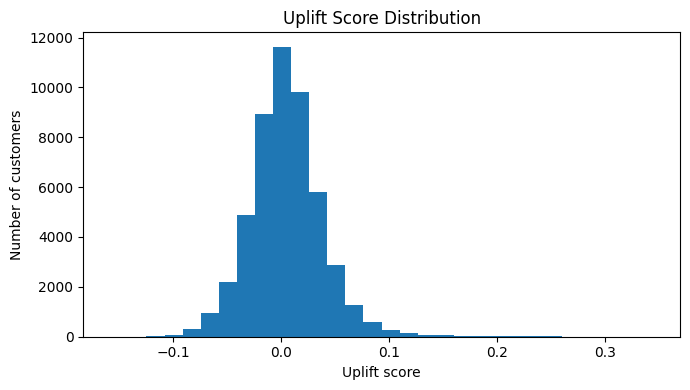

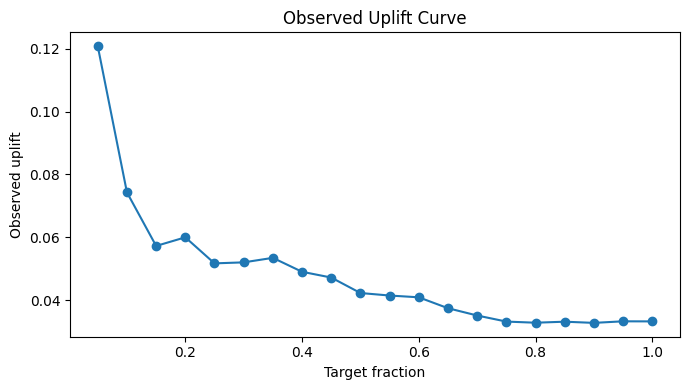

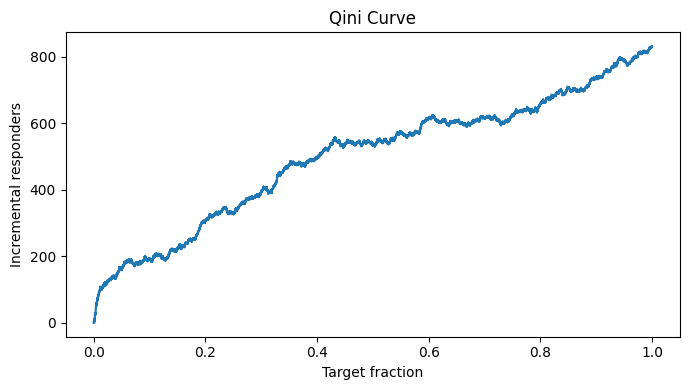

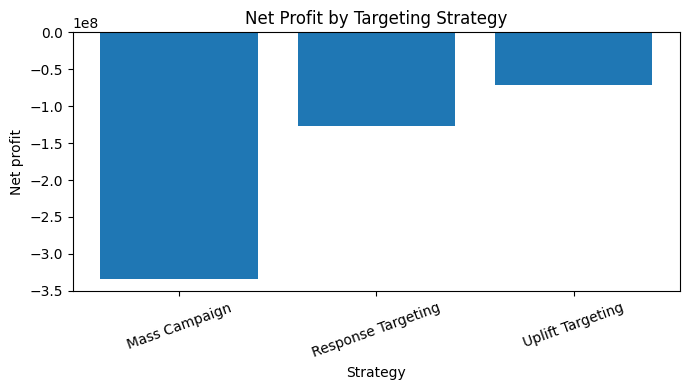

Report assets exported to: /content/AutoLift_DM_Materials/05_report_assets
- economic_summary.png
- qini_curve.png
- sample_customer_uplift_scores.csv
- sample_gp_rules.csv
- uplift_curve.png
- uplift_score_distribution.png


In [10]:
# ============================================================
# 8. Export report assets and backend sample files
# ============================================================

from datetime import datetime, timezone

REPORT_DIR.mkdir(parents=True, exist_ok=True)

CURRENT_TIMESTAMP = datetime.now(timezone.utc).isoformat()

# ------------------------------------------------------------
# 8.1. Backend sample: customer_uplift_scores.csv
# ------------------------------------------------------------

sample_backend = (
    valid_results
    .sort_values("uplift_score", ascending=False)
    .head(1000)
    .copy()
)

sample_backend["campaign_id"] = "demo-campaign-x5"
sample_backend["model_version"] = UPLIFT_MODEL_VERSION
sample_backend["scored_at"] = CURRENT_TIMESTAMP

sample_backend = sample_backend.rename(columns={
    "p_treatment": "treatment_probability",
    "p_control": "control_probability",
})

required_backend_cols = [
    "customer_id",
    "campaign_id",
    "uplift_score",
    "treatment_probability",
    "control_probability",
    "segment",
    "model_version",
    "scored_at",
]

for col in required_backend_cols:
    if col not in sample_backend.columns:
        sample_backend[col] = None

sample_backend = sample_backend[required_backend_cols]

sample_backend.to_csv(
    REPORT_DIR / "sample_customer_uplift_scores.csv",
    index=False,
)

display(sample_backend.head())


# ------------------------------------------------------------
# 8.2. Backend sample: gp_rules.csv
# ------------------------------------------------------------

sample_gp_rules = pd.DataFrame([
    {
        "rule_id": "R001",
        "rule_text": "frequency_total > Q50 AND recency_days <= Q50",
        "precision": 0.70,
        "recall": 0.42,
        "f1_score": 0.52,
        "coverage": 0.18,
        "model_version": UPLIFT_MODEL_VERSION,
        "created_at": CURRENT_TIMESTAMP,
    },
    {
        "rule_id": "R002",
        "rule_text": "monetary_total > Q75 OR avg_basket_value > Q75",
        "precision": 0.64,
        "recall": 0.38,
        "f1_score": 0.48,
        "coverage": 0.22,
        "model_version": UPLIFT_MODEL_VERSION,
        "created_at": CURRENT_TIMESTAMP,
    },
])

sample_gp_rules.to_csv(
    REPORT_DIR / "sample_gp_rules.csv",
    index=False,
)

display(sample_gp_rules)


# ------------------------------------------------------------
# 8.3. Plot: uplift score distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.hist(valid_results["uplift_score"], bins=30)
plt.title("Uplift Score Distribution")
plt.xlabel("Uplift score")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.savefig(REPORT_DIR / "uplift_score_distribution.png", dpi=160)
plt.show()


# ------------------------------------------------------------
# 8.4. Plot: observed uplift curve
# ------------------------------------------------------------

if "observed_uplift" not in uplift_curve_df.columns:
    raise ValueError("uplift_curve_df must contain observed_uplift column.")

plt.figure(figsize=(7, 4))
plt.plot(
    uplift_curve_df["target_fraction"],
    uplift_curve_df["observed_uplift"],
    marker="o",
)
plt.title("Observed Uplift Curve")
plt.xlabel("Target fraction")
plt.ylabel("Observed uplift")
plt.tight_layout()
plt.savefig(REPORT_DIR / "uplift_curve.png", dpi=160)
plt.show()


# ------------------------------------------------------------
# 8.5. Plot: Qini curve
# ------------------------------------------------------------

if "qini" not in qini_curve_df.columns:
    raise ValueError("qini_curve_df must contain qini column.")

plt.figure(figsize=(7, 4))
plt.plot(
    qini_curve_df["target_fraction"],
    qini_curve_df["qini"],
)
plt.title("Qini Curve")
plt.xlabel("Target fraction")
plt.ylabel("Incremental responders")
plt.tight_layout()
plt.savefig(REPORT_DIR / "qini_curve.png", dpi=160)
plt.show()


# ------------------------------------------------------------
# 8.6. Plot: economic summary
# ------------------------------------------------------------

if "strategy" not in economic_summary.columns or "net_profit" not in economic_summary.columns:
    raise ValueError("economic_summary must contain strategy and net_profit columns.")

plt.figure(figsize=(7, 4))
plt.bar(
    economic_summary["strategy"],
    economic_summary["net_profit"],
)
plt.title("Net Profit by Targeting Strategy")
plt.ylabel("Net profit")
plt.xlabel("Strategy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(REPORT_DIR / "economic_summary.png", dpi=160)
plt.show()


# ------------------------------------------------------------
# 8.7. Summary
# ------------------------------------------------------------

print("Report assets exported to:", REPORT_DIR)

for path in sorted(REPORT_DIR.glob("*")):
    print("-", path.name)

## 9. Zip package

In [11]:
# ============================================================
# 9. ZIP export
# ============================================================

zip_path = Path("/content/AutoLift_DM_Materials.zip")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(zip_path).replace(".zip", ""),
    format="zip",
    root_dir=BASE_DIR,
)

print("ZIP created:", zip_path)

ZIP created: /content/AutoLift_DM_Materials.zip
